In [61]:
import pandas as pd
import requests
import numpy as np

url = "https://uk.wikipedia.org/wiki/Населення_України"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

birth_rate_df = tables[13]

year_cols = birth_rate_df.columns[1:]

def convert_value(x):
    try:
        return float(x) / 10
    except:
        return np.nan

for col in year_cols:
    birth_rate_df[col] = birth_rate_df[col].apply(convert_value)

print(birth_rate_df)












/tmp/ipython-input-4246514423.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   NaN
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

In [62]:
print(birth_rate_df.head())

             Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0              Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
1         Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2         Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3  Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4          Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN


In [63]:
print(birth_rate_df.shape)

(28, 9)


In [64]:
print(birth_rate_df.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


In [65]:
for col in birth_rate_df.columns:
    if birth_rate_df[col].isnull().any():
        birth_rate_df[col] = pd.to_numeric(birth_rate_df[col], errors="coerce")

print(birth_rate_df.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


In [66]:
nan_percent = (birth_rate_df.isnull().sum() / len(birth_rate_df)) * 100
print(nan_percent.round(1).astype(str) + '%')

Регіон     0.0%
1950       7.1%
1960       3.6%
1970       3.6%
1990       0.0%
2000       0.0%
2012       0.0%
2014       7.1%
2019      14.3%
dtype: object


In [67]:
birth_rate_df_l = birth_rate_df.iloc[:-1]
print(birth_rate_df_l)

               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6   NaN   NaN
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   NaN
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   NaN
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

In [68]:
birth_rate_df = birth_rate_df.fillna(birth_rate_df.mean(numeric_only=True)).round(1)
print(birth_rate_df)

               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6  11.1   8.0
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2   8.0
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1   8.0
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

In [69]:
avg_2019 = birth_rate_df[birth_rate_df['Регіон'] == 'Україна']['2019'].values[0]

reg_birth_2019 = birth_rate_df[
    (birth_rate_df['2019'] > avg_2019) & (birth_rate_df['Регіон'] != 'Україна')
]['Регіон'].tolist()

print(reg_birth_2019)


['Волинська', 'Закарпатська', 'Івано-Франківська', 'Львівська', 'Одеська', 'Рівненська', 'Чернівецька', 'Київ']


In [70]:
max_index = birth_rate_df['2014'].idxmax()
region_max_birth_2014 = birth_rate_df.loc[max_index, 'Регіон']

print(region_max_birth_2014)


Рівненська


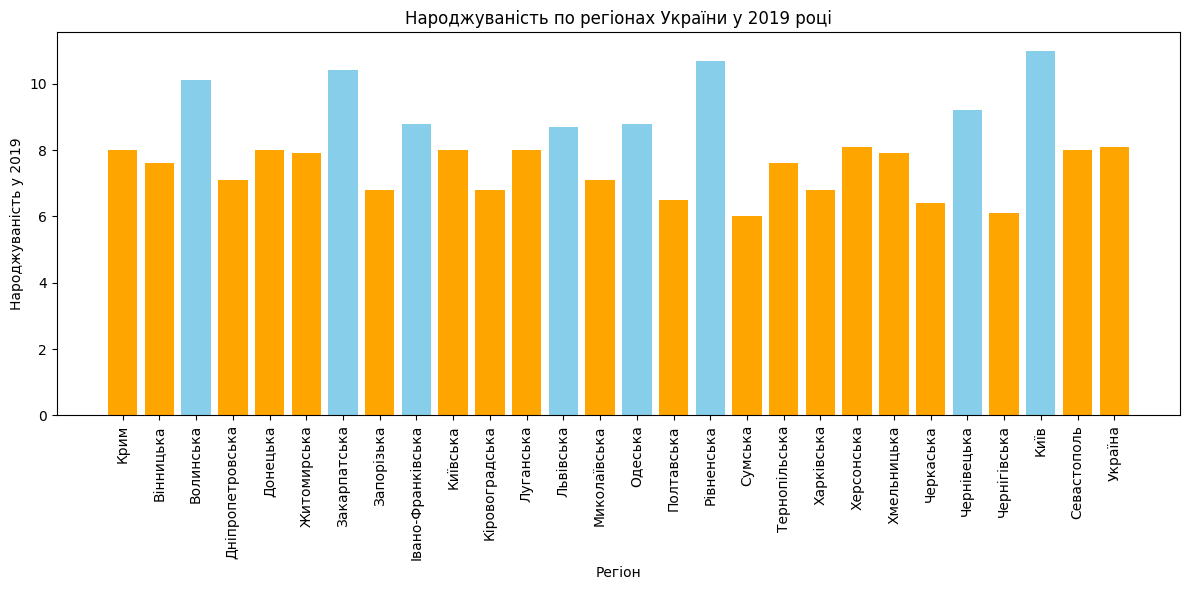

In [81]:
import matplotlib.pyplot as plt

regions = birth_rate_df['Регіон']
birth_2019 = birth_rate_df['2019']

colors = ['skyblue' if x > avg_2019 else 'orange' for x in birth_2019]

plt.figure(figsize=(12, 6))
plt.bar(regions, birth_2019, color=colors)
plt.xticks(rotation=90)
plt.xlabel('Регіон')
plt.ylabel('Народжуваність у 2019')
plt.title('Народжуваність по регіонах України у 2019 році')
plt.tight_layout()
plt.show()

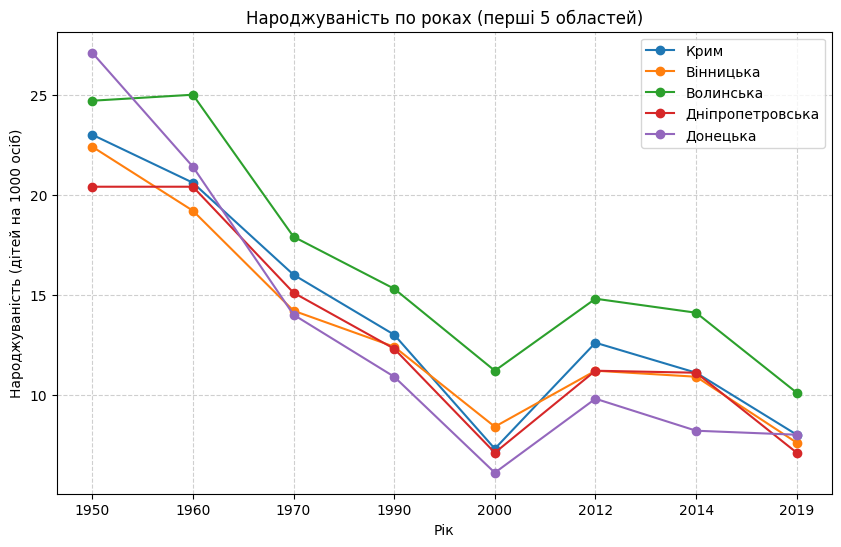

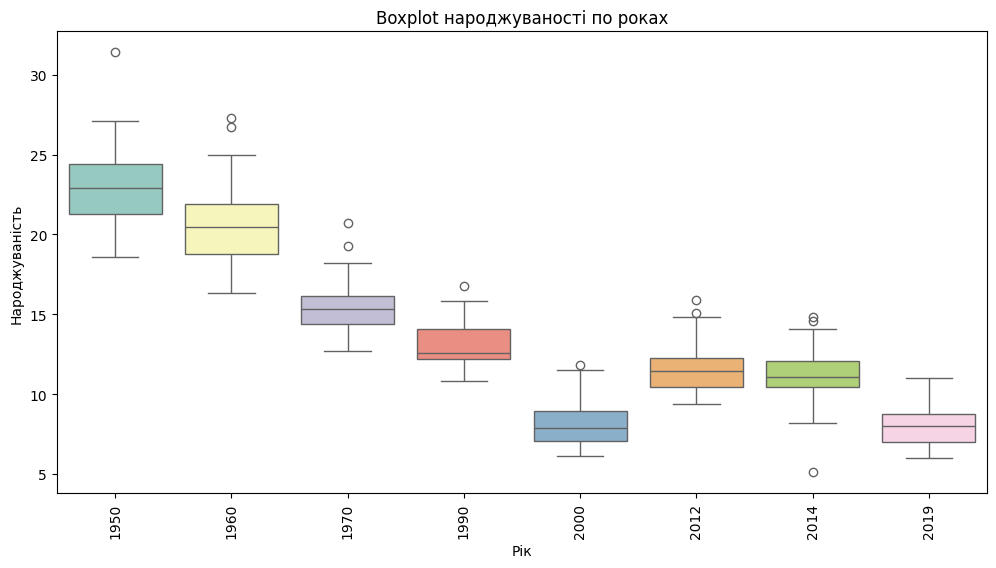

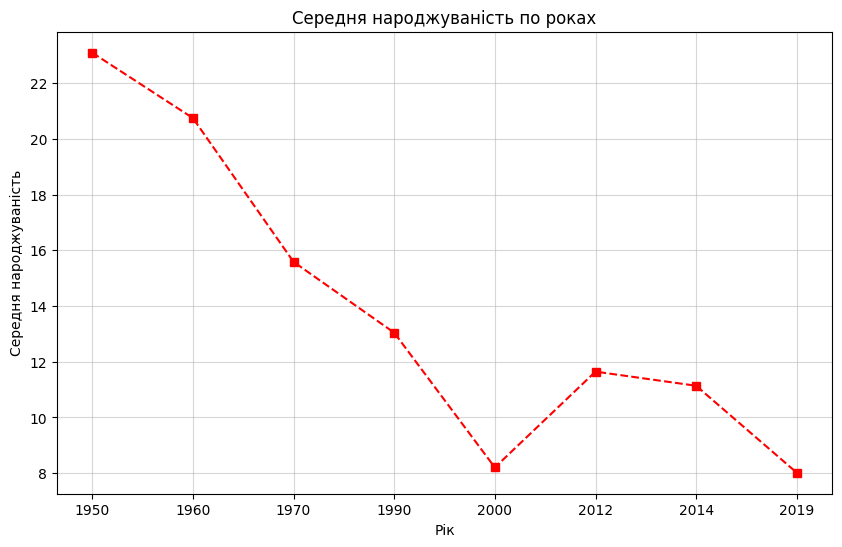

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

years = year_cols
regions = birth_rate_df.iloc[:, 0]
data_numeric = birth_rate_df[years].astype(float)

# Лінійний графік народжуваності для кількох областей
plt.figure(figsize=(10,6))
for i in range(5):
    plt.plot(years, data_numeric.iloc[i], marker='o', label=regions[i])
plt.title("Народжуваність по роках (перші 5 областей)")
plt.xlabel("Рік")
plt.ylabel("Народжуваність (дітей на 1000 осіб)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Порівняння розподілу народжуваності по роках
plt.figure(figsize=(12,6))
sns.boxplot(data=data_numeric, palette="Set3")
plt.title("Boxplot народжуваності по роках")
plt.xlabel("Рік")
plt.ylabel("Народжуваність")
plt.xticks(ticks=range(len(years)), labels=years, rotation=90)
plt.show()

# Середня народжуваність по роках
avg_birth_rate = data_numeric.mean(axis=0)
plt.figure(figsize=(10,6))
plt.plot(years, avg_birth_rate, marker='s', color='red', linestyle='--')
plt.title("Середня народжуваність по роках")
plt.xlabel("Рік")
plt.ylabel("Середня народжуваність")
plt.grid(True, alpha=0.5)
plt.show()
